In [18]:

import os

# Pick physical GPU 2 before importing torch in this kernel session.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from glp.denoiser import load_glp
from glp import flow_matching, script_eval, script_steer
from glp.utils_acts import save_acts
from gemma2_pipeline.loading import iter_fineweb_texts, load_model_and_tokenizer
from gemma2_pipeline.preprocess import batch_items
from gemma2_pipeline.settings import FineWebSourceConfig

In [19]:

import torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("Visible logical GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Logical cuda:0:", torch.cuda.get_device_name(0))

CUDA_VISIBLE_DEVICES: 0
Visible logical GPUs: 1
Logical cuda:0: NVIDIA A30


**Load the GLP**

You can just put the HuggingFace repo and the checkpoint will be automatically downloaded for you.

In [20]:
# With CUDA_VISIBLE_DEVICES=2, physical GPU 2 is remapped to logical cuda:0.
device = "cuda:0"

# Your Gemma GLP checkpoint (local folder or HF repo id).
glp_name = "PQPQPQHUST/glp-gemma"
glp_ckpt = "1B/1000M"

# Gemma LLM setup for streaming reference activations and steering.
hf_model_name = "google/gemma-2-2b-it"
hf_layer = 14

In [21]:
import time

t0 = time.time()
try:
    model, mean, var = load_glp(glp_name, device=device, checkpoint=glp_ckpt, local_files_only=True)
    print("Loaded GLP from local cache.")
except Exception as cache_err:
    print(f"Local cache miss ({type(cache_err).__name__}), falling back to online download.")
    model, mean, var = load_glp(glp_name, device=device, checkpoint=glp_ckpt, local_files_only=False)
model = model.to(torch.bfloat16)
embedding_dim = model.denoiser.model.d_input
print(f"GLP loaded in {time.time() - t0:.1f}s | embedding_dim={embedding_dim}")
print(f"Normalizer method: {getattr(model.normalizer, 'normalization_method', 'gaussian')}")

Loaded GLP from local cache.
GLP loaded in 4.5s | embedding_dim=2304
Normalizer method: gaussian


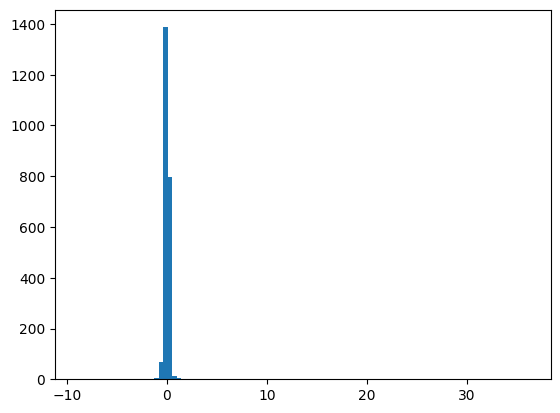

In [22]:
plt.hist(mean.cpu().numpy(), bins=100)
plt.show()

**Checking GLP Quality**

Now that we've loaded up the model, we can sanity check that it's working by generating some activations.

In [23]:
def generate_activations(num_timesteps, batch_size, generator=None):
    print("Generating activations...")
    noise = torch.randn(batch_size, 1, embedding_dim, generator=generator).to(device)
    gen_latents = flow_matching.sample(model, noise, num_timesteps=num_timesteps)
    # map normalized latents back to activation space (gaussian or log_norm inverse)
    gen_latents = model.normalizer.denormalize(gen_latents)
    return gen_latents


def stream_reference_activations(
    hf_model,
    hf_tokenizer,
    layer,
    num_vectors=20000,
    dataset_name="HuggingFaceFW/fineweb",
    dataset_config="sample-10BT",
    split="train",
    text_field="text",
    max_documents=None,
    document_batch_size=16,
    forward_batch_size=1,
    max_length=1024,
    drop_bos=True,
):
    tracedict_config = {
        "layer_prefix": "transformer.h",
        "layers": [layer],
        "retain": "output",
    }
    fineweb_cfg = FineWebSourceConfig(
        dataset_name=dataset_name,
        dataset_config=dataset_config,
        split=split,
        text_field=text_field,
        streaming=True,
        max_documents=max_documents,
    )

    text_iter = iter_fineweb_texts(fineweb_cfg)
    chunks = []
    vectors_written = 0
    for text_batch in tqdm(
        batch_items(text_iter, document_batch_size),
        desc="Streaming FineWeb acts",
        dynamic_ncols=True,
    ):
        acts = save_acts(
            hf_model=hf_model,
            hf_tokenizer=hf_tokenizer,
            text=text_batch,
            tracedict_config=tracedict_config,
            padding_side="right",
            token_idx="all",
            batch_size=forward_batch_size,
            max_length=max_length,
        )
        vecs = acts[:, 0, :, :]
        if drop_bos and vecs.shape[1] > 1:
            vecs = vecs[:, 1:, :]
        vecs = vecs.reshape(-1, vecs.shape[-1])
        if vecs.shape[0] == 0:
            continue

        remaining = num_vectors - vectors_written
        vecs = vecs[:remaining]
        chunks.append(vecs.cpu())
        vectors_written += vecs.shape[0]
        if vectors_written >= num_vectors:
            break

    if vectors_written == 0:
        raise RuntimeError("No reference activations were collected from FineWeb streaming.")

    ref_latents = torch.cat(chunks, dim=0)[:, None, :]
    print(f"Collected {ref_latents.shape[0]} streamed reference vectors.")
    return ref_latents



def compute_fd(ref_latents, gen_latents):
    ref_vecs = ref_latents[:, 0, :].detach().cpu().float()
    ref_vecs = (ref_vecs - mean.cpu()) / torch.sqrt(var.cpu() + 1e-8)
    gen_vecs = gen_latents[:, 0, :].detach().cpu().float()
    gen_vecs = (gen_vecs - mean.cpu()) / torch.sqrt(var.cpu() + 1e-8)
    n = min(ref_vecs.shape[0], gen_vecs.shape[0])
    if n < 2:
        raise ValueError("Need at least 2 vectors per set to compute Frechet Distance.")
    return script_eval.rep_fd(ref_vecs[:n].float().numpy(), gen_vecs[:n].float().numpy())


def plot_pca(num_timesteps, batch_size, ref_latents, gen_latents):
    gen_latents = gen_latents[:, 0, :].detach().cpu()
    ref_latents = ref_latents[:, 0, :].detach().cpu()
    gen_latents = gen_latents[:batch_size, :]
    ref_latents = ref_latents[:batch_size, :]
    title = f"Num Timesteps: {num_timesteps}"
    print("Plotting PCA...")
    return script_eval.plot_pca(
        ref_latents,
        gen_latents,
        label_X="Real",
        label_Y="Generated",
        title=title,
        alpha=0.8,
        half_mask=num_timesteps >= 10,
    )

In [24]:
from pathlib import Path

ref_num_vectors = 50000
ref_cache = Path(f"data/frechet-stream-{hf_model_name.split('/')[-1]}-layer{hf_layer}-{ref_num_vectors}.pt")

if ref_cache.exists():
    print(f"Loading cached streamed reference activations from {ref_cache}")
    ref_latents = torch.load(ref_cache)["activations"]
else:
    print("Loading Gemma model for streaming references...")
    hf_model, hf_tokenizer = load_model_and_tokenizer(
        model_name=hf_model_name,
        device=device,
        torch_dtype_name="bfloat16",
    )
    ref_latents = stream_reference_activations(
        hf_model=hf_model,
        hf_tokenizer=hf_tokenizer,
        layer=hf_layer,
        num_vectors=ref_num_vectors,
        dataset_name="HuggingFaceFW/fineweb",
        dataset_config="sample-10BT",
        split="train",
        text_field="text",
        document_batch_size=16,
        forward_batch_size=1,
        max_length=1024,
    ).float()
    ref_cache.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"activations": ref_latents}, ref_cache)
    print(f"Saved streamed references to {ref_cache}")

Loading cached streamed reference activations from data/frechet-stream-gemma-2-2b-it-layer14-50000.pt


**Part 1: Normal Frechet Distance**

This is the original full-covariance Frechet Distance evaluation against streamed reference activations.


In [25]:
# Keep these evaluation hyperparameters aligned with glp_demo.ipynb
batch_size = 10000
eval_timesteps = [1, 20]
fd_eval_vectors = min(batch_size, ref_latents.shape[0])


Generating activations...


1it [00:00,  2.69it/s]


Plotting PCA...
Generating activations...


20it [00:07,  2.83it/s]


Plotting PCA...


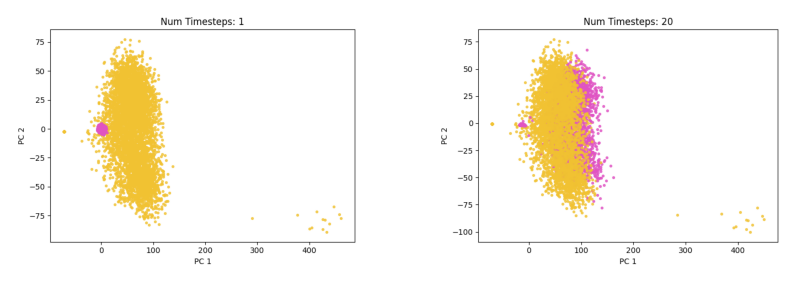

,frechet_distance
num_timesteps,
1,3600.92
20,2116.36


In [26]:
# Run generation and compute the original full-covariance FD.
generator = torch.Generator().manual_seed(4)
pca_plots = []
fd_rows = []
generated_latents_by_step = {}

for num_timesteps in eval_timesteps:
    gen_latents = generate_activations(num_timesteps, batch_size, generator=generator)
    generated_latents_by_step[num_timesteps] = gen_latents.detach().cpu()
    pca_plot = plot_pca(num_timesteps, batch_size, ref_latents, gen_latents)
    pca_plots.append(pca_plot)
    fd_rows.append({
        "num_timesteps": num_timesteps,
        "frechet_distance": compute_fd(ref_latents[:fd_eval_vectors], gen_latents[:fd_eval_vectors]),
    })

plt.figure(figsize=(5 * len(pca_plots), 5))
for i in range(len(pca_plots)):
    plt.subplot(1, len(pca_plots), i + 1)
    plt.imshow(pca_plots[i])
    plt.axis("off")
plt.show()

fd_df = pd.DataFrame(fd_rows).set_index("num_timesteps").sort_index()
fd_df.round(2)


**Part 2: Top GLP-Variance Dimension Attribution**

The target dimensions are selected only from `var` returned by `load_glp()`. This `var` is the GLP training activation variance estimate, so the analysis asks whether the highest-training-variance Gemma dimensions dominate FD. The diagonal attribution is approximate, and the gap table checks whether its total stays close to the original full FD.


In [27]:
def _activation_vectors(latents):
    """Return [n, d] activation vectors on CPU float32 from [n, 1, d] or [n, d]."""
    vecs = latents.detach().cpu().float()
    if vecs.ndim == 3:
        vecs = vecs[:, 0, :]
    if vecs.ndim != 2:
        raise ValueError(f"Expected [n, d] or [n, 1, d], got {tuple(vecs.shape)}")
    return vecs


def _standardize_with_glp_stats(vecs):
    return (vecs - mean.detach().cpu().float()) / torch.sqrt(var.detach().cpu().float() + 1e-8)


def top_glp_variance_dimensions(k=50):
    glp_var = var.detach().cpu().float().flatten()
    top_vals, top_dims = torch.topk(glp_var, k=min(k, glp_var.numel()), largest=True)
    return pd.DataFrame({
        "rank": np.arange(1, top_dims.numel() + 1),
        "dim": top_dims.numpy().astype(int),
        "glp_var": top_vals.numpy(),
        "glp_std": torch.sqrt(top_vals).numpy(),
        "glp_var_share": (top_vals / glp_var.sum()).numpy(),
    })


def _prepare_fd_vectors(ref_latents, gen_latents, normalize=True):
    ref_raw = _activation_vectors(ref_latents)
    gen_raw = _activation_vectors(gen_latents)
    n = min(ref_raw.shape[0], gen_raw.shape[0])
    if n < 2:
        raise ValueError("Need at least 2 vectors per set.")
    ref_raw = ref_raw[:n]
    gen_raw = gen_raw[:n]
    ref = _standardize_with_glp_stats(ref_raw) if normalize else ref_raw
    gen = _standardize_with_glp_stats(gen_raw) if normalize else gen_raw
    return ref_raw, gen_raw, ref, gen


def diagonal_fd_attribution(ref_latents, gen_latents, normalize=True, eps=1e-8):
    """Per-dimension diagonal Gaussian FD contribution."""
    _, _, ref, gen = _prepare_fd_vectors(ref_latents, gen_latents, normalize=normalize)
    ref_mu = ref.mean(dim=0)
    gen_mu = gen.mean(dim=0)
    ref_var_emp = ref.var(dim=0, unbiased=True)
    gen_var_emp = gen.var(dim=0, unbiased=True)

    mean_component = (ref_mu - gen_mu).pow(2)
    variance_component = (torch.sqrt(ref_var_emp.clamp_min(eps)) - torch.sqrt(gen_var_emp.clamp_min(eps))).pow(2)
    fd_diag_contribution = mean_component + variance_component

    df = pd.DataFrame({
        "dim": np.arange(ref.shape[1]),
        "fd_diag_contribution": fd_diag_contribution.numpy(),
        "fd_mean_component": mean_component.numpy(),
        "fd_variance_component": variance_component.numpy(),
    })
    df["fd_diag_share"] = df["fd_diag_contribution"] / df["fd_diag_contribution"].sum()
    return df.sort_values("fd_diag_contribution", ascending=False).reset_index(drop=True)


def compare_full_vs_diagonal_fd(ref_latents, gen_latents):
    """Compare the original full FD with the diagonal FD sum in the same normalized space."""
    attr = diagonal_fd_attribution(ref_latents, gen_latents, normalize=True)
    diagonal_fd = float(attr["fd_diag_contribution"].sum())
    full_fd = float(compute_fd(ref_latents, gen_latents))
    return pd.DataFrame([{
        "full_fd": full_fd,
        "diagonal_fd": diagonal_fd,
        "full_minus_diagonal": full_fd - diagonal_fd,
        "abs_relative_gap": abs(full_fd - diagonal_fd) / (abs(full_fd) + 1e-8),
        "diagonal_to_full_ratio": diagonal_fd / (full_fd + 1e-8),
    }])


def top_glp_var_attribution_table(ref_latents, gen_latents, top_var_k=50):
    """Join top GLP-training-variance dims with approximate diagonal FD attribution."""
    high_var_df = top_glp_variance_dimensions(top_var_k)
    attr_df = diagonal_fd_attribution(ref_latents, gen_latents, normalize=True)
    full_fd = float(compute_fd(ref_latents, gen_latents))
    attr_df["fd_full_rescaled_contribution"] = attr_df["fd_diag_share"] * full_fd
    return high_var_df.merge(attr_df, on="dim", how="left")


def _matrix_sqrt_psd(mat, eps=1e-6):
    eigvals, eigvecs = torch.linalg.eigh(mat)
    eigvals = eigvals.clamp_min(eps)
    return (eigvecs * torch.sqrt(eigvals).unsqueeze(0)) @ eigvecs.T


def _torch_cov(x):
    x = x - x.mean(dim=0, keepdim=True)
    return x.T @ x / (x.shape[0] - 1)


def differentiable_full_fd(ref_vecs, gen_vecs, eps=1e-5):
    """Differentiable full FD/W2 between Gaussian fits in a selected subspace."""
    mu_ref = ref_vecs.mean(dim=0)
    mu_gen = gen_vecs.mean(dim=0)
    cov_ref = _torch_cov(ref_vecs)
    cov_gen = _torch_cov(gen_vecs)
    eye = torch.eye(cov_ref.shape[0], device=cov_ref.device, dtype=cov_ref.dtype)
    cov_ref = cov_ref + eps * eye
    cov_gen = cov_gen + eps * eye
    cov_ref_sqrt = _matrix_sqrt_psd(cov_ref, eps=eps)
    middle = cov_ref_sqrt @ cov_gen @ cov_ref_sqrt
    middle_sqrt = _matrix_sqrt_psd((middle + middle.T) / 2, eps=eps)
    mean_term = (mu_ref - mu_gen).pow(2).sum()
    cov_term = torch.trace(cov_ref + cov_gen - 2 * middle_sqrt)
    return mean_term + cov_term


def gradient_fd_attribution_on_dims(ref_latents, gen_latents, dims, max_vectors=2048, eps=1e-5):
    """Backprop full FD in only the selected dimensions and aggregate grad*activation."""
    _, _, ref, gen = _prepare_fd_vectors(ref_latents, gen_latents, normalize=True)
    n = min(max_vectors, ref.shape[0], gen.shape[0])
    dims = torch.as_tensor(list(dims), dtype=torch.long)
    ref_sub = ref[:n, dims].double()
    gen_sub = gen[:n, dims].double().clone().detach().requires_grad_(True)
    fd = differentiable_full_fd(ref_sub, gen_sub, eps=eps)
    fd.backward()
    grad_x_input = (gen_sub.grad * gen_sub.detach()).abs().mean(dim=0)
    grad_abs = gen_sub.grad.abs().mean(dim=0)
    return pd.DataFrame({
        "dim": dims.numpy().astype(int),
        "fd_grad_abs_mean": grad_abs.detach().cpu().numpy(),
        "fd_grad_x_input_abs_mean": grad_x_input.detach().cpu().numpy(),
        "subspace_full_fd": float(fd.detach().cpu()),
    }).sort_values("fd_grad_x_input_abs_mean", ascending=False).reset_index(drop=True)


In [28]:
# Analyze only the dimensions with highest GLP training variance.
attribution_timesteps = max(eval_timesteps)
attr_ref = ref_latents[:fd_eval_vectors]
attr_gen = generated_latents_by_step[attribution_timesteps][:fd_eval_vectors]
top_var_k = 50

top_var_attr_df = top_glp_var_attribution_table(attr_ref, attr_gen, top_var_k=top_var_k)
fd_gap_df = compare_full_vs_diagonal_fd(attr_ref, attr_gen)

print(f"Selected timestep: {attribution_timesteps}")
print(f"Original full FD: {fd_gap_df.loc[0, 'full_fd']:.4f}")
print(f"Diagonal FD approximation: {fd_gap_df.loc[0, 'diagonal_fd']:.4f}")
print(f"Approximation relative gap: {100 * fd_gap_df.loc[0, 'abs_relative_gap']:.2f}%")
if fd_gap_df.loc[0, "abs_relative_gap"] > 0.20:
    print("Warning: diagonal attribution is far from full FD; rely more on gradient and ablation below.")

print(f"Top {top_var_k} GLP-var dimensions contain {100 * top_var_attr_df['glp_var_share'].sum():.2f}% of total GLP training variance")
print(f"Top {top_var_k} GLP-var dimensions explain {100 * top_var_attr_df['fd_diag_share'].sum():.2f}% of diagonal FD attribution")
print(f"Rescaled approximate full-FD contribution from top {top_var_k}: {top_var_attr_df['fd_full_rescaled_contribution'].sum():.4f}")

display(fd_gap_df)
display(top_var_attr_df)

# Optional backward attribution: full FD gradient restricted to the top GLP-var subspace.
grad_top_k = 50
grad_eval_vectors = min(2048, fd_eval_vectors)
grad_attr_df = gradient_fd_attribution_on_dims(
    attr_ref,
    attr_gen,
    dims=top_var_attr_df["dim"].head(grad_top_k).tolist(),
    max_vectors=grad_eval_vectors,
)
display(grad_attr_df)


Selected timestep: 20
Original full FD: 2116.3590
Diagonal FD approximation: 1417.7620
Approximation relative gap: 33.01%
Top 50 GLP-var dimensions contain 50.97% of total GLP training variance
Top 50 GLP-var dimensions explain 2.19% of diagonal FD attribution
Rescaled approximate full-FD contribution from top 50: 46.3952


,full_fd,diagonal_fd,full_minus_diagonal,abs_relative_gap,diagonal_to_full_ratio
0,2116.359004,1417.761963,698.597041,0.330094,0.669906


,rank,dim,glp_var,glp_std,glp_var_share,fd_diag_contribution,fd_mean_component,fd_variance_component,fd_diag_share,fd_full_rescaled_contribution
0,1,334,3027.458984,55.022350,0.245079,0.880949,0.644192,0.236756,0.000621,1.315033
1,2,1068,367.728394,19.176245,0.029768,0.396919,0.177838,0.219081,0.000280,0.592499
2,3,1570,361.151703,19.003992,0.029236,0.542706,0.370607,0.172099,0.000383,0.810123
3,4,1046,284.778473,16.875381,0.023053,0.398429,0.143872,0.254557,0.000281,0.594753
4,5,682,217.677460,14.753897,0.017621,1.066902,0.721397,0.345504,0.000753,1.592614
5,6,1645,153.482361,12.388800,0.012425,0.882832,0.485991,0.396841,0.000623,1.317844
6,7,1546,120.481750,10.976418,0.009753,0.343687,0.088907,0.254780,0.000242,0.513038
7,8,113,108.370941,10.410136,0.008773,0.516483,0.057516,0.458968,0.000364,0.770979
8,9,1824,100.830124,10.041420,0.008162,0.716958,0.213911,0.503047,0.000506,1.070236
9,10,784,83.398109,9.132257,0.006751,0.531759,0.059237,0.472522,0.000375,0.793781


,dim,fd_grad_abs_mean,fd_grad_x_input_abs_mean,subspace_full_fd
0,1546,0.000976,0.000837,49.120824
1,1234,0.000994,0.000794,49.120824
2,334,0.000973,0.000732,49.120824
3,641,0.000820,0.000724,49.120824
4,682,0.000883,0.000681,49.120824
5,1405,0.000790,0.000676,49.120824
6,1570,0.000797,0.000643,49.120824
7,588,0.000804,0.000591,49.120824
8,1824,0.000811,0.000577,49.120824
9,714,0.000828,0.000575,49.120824


**Part 3: Full-FD Ablation on Top GLP-Variance Dimensions**

This ablation uses the same top dimensions from `load_glp()` variance. Because generated vectors and reference vectors have no one-to-one pairing, selected generated coordinates are replaced by values sampled from random reference rows. The metric is still the original full FD. A large FD reduction means the high-GLP-variance dimensions materially drive the FD gap.


In [29]:
def patch_top_glp_var_dimensions_from_reference(ref_latents, gen_latents, dims, seed=0):
    """Patch selected generated coordinates using the empirical reference distribution."""
    ref_vecs = _activation_vectors(ref_latents)
    gen_vecs = _activation_vectors(gen_latents).clone()
    n = min(ref_vecs.shape[0], gen_vecs.shape[0])
    ref_vecs = ref_vecs[:n]
    gen_vecs = gen_vecs[:n]
    dims = torch.as_tensor(list(dims), dtype=torch.long)
    if dims.numel() == 0:
        return gen_vecs[:, None, :]

    generator = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=generator)
    gen_vecs[:, dims] = ref_vecs[perm][:, dims]
    return gen_vecs[:, None, :]


def ablate_top_glp_var_dimensions(ref_latents, gen_latents, top_var_df, group_sizes=(1, 5, 10, 25, 50), seeds=(0, 1, 2)):
    """Patch cumulative top-GLP-var dimensions and recompute original full FD."""
    ranked_dims = top_var_df["dim"].astype(int).tolist()
    baseline_fd = float(compute_fd(ref_latents, gen_latents))
    rows = []
    for k in group_sizes:
        dims = ranked_dims[:min(k, len(ranked_dims))]
        for seed in seeds:
            patched_gen = patch_top_glp_var_dimensions_from_reference(ref_latents, gen_latents, dims, seed=seed)
            patched_fd = float(compute_fd(ref_latents, patched_gen))
            reduction = baseline_fd - patched_fd
            rows.append({
                "num_dims_patched": len(dims),
                "dims": dims,
                "seed": seed,
                "baseline_full_fd": baseline_fd,
                "patched_full_fd": patched_fd,
                "fd_reduction": reduction,
                "fd_reduction_share": reduction / (baseline_fd + 1e-8),
            })

    replicate_df = pd.DataFrame(rows)
    summary_df = (
        replicate_df
        .groupby("num_dims_patched", as_index=False)
        .agg(
            baseline_full_fd=("baseline_full_fd", "first"),
            patched_full_fd_mean=("patched_full_fd", "mean"),
            patched_full_fd_std=("patched_full_fd", "std"),
            fd_reduction_mean=("fd_reduction", "mean"),
            fd_reduction_std=("fd_reduction", "std"),
            fd_reduction_share_mean=("fd_reduction_share", "mean"),
            fd_reduction_share_std=("fd_reduction_share", "std"),
            dims=("dims", "first"),
        )
    )
    return summary_df, replicate_df


In [30]:
patch_group_sizes = (1, 5, 10, 25, 50)
patch_seeds = (0, 1, 2)

fd_patch_ablation_df, fd_patch_ablation_replicates = ablate_top_glp_var_dimensions(
    attr_ref,
    attr_gen,
    top_var_attr_df,
    group_sizes=patch_group_sizes,
    seeds=patch_seeds,
)

print("Patched dimensions are cumulative top indices from load_glp() var.")
print(f"Seeds: {patch_seeds}")
display(fd_patch_ablation_df.drop(columns=["dims"]))
fd_patch_ablation_df


Patched dimensions are cumulative top indices from load_glp() var.
Seeds: (0, 1, 2)


,num_dims_patched,baseline_full_fd,patched_full_fd_mean,patched_full_fd_std,fd_reduction_mean,fd_reduction_std,fd_reduction_share_mean,fd_reduction_share_std
0,1,2116.359004,2117.300029,0.020059,-0.941025,0.020059,-0.000445,0.000009
1,5,2116.359004,2122.078324,0.069287,-5.719319,0.069287,-0.002702,0.000033
2,10,2116.359004,2125.577659,0.166421,-9.218655,0.166421,-0.004356,0.000079
3,25,2116.359004,2133.848183,0.240091,-17.489179,0.240091,-0.008264,0.000113
4,50,2116.359004,2136.709126,0.263108,-20.350122,0.263108,-0.009616,0.000124


,num_dims_patched,baseline_full_fd,patched_full_fd_mean,patched_full_fd_std,fd_reduction_mean,fd_reduction_std,fd_reduction_share_mean,fd_reduction_share_std,dims
0,1,2116.359004,2117.300029,0.020059,-0.941025,0.020059,-0.000445,0.000009,[334]
1,5,2116.359004,2122.078324,0.069287,-5.719319,0.069287,-0.002702,0.000033,"[334, 1068, 1570, 1046, 682]"
2,10,2116.359004,2125.577659,0.166421,-9.218655,0.166421,-0.004356,0.000079,"[334, 1068, 1570, 1046, 682, 1645, 1546, 113, 1824, 784]"
3,25,2116.359004,2133.848183,0.240091,-17.489179,0.240091,-0.008264,0.000113,"[334, 1068, 1570, 1046, 682, 1645, 1546, 113, 1824, 784, 2106, 714, 1170, 1807, 948, 2257, 1149, 1405, 567, 1450, 987, 1699, 1261, 540, 557]"
4,50,2116.359004,2136.709126,0.263108,-20.350122,0.263108,-0.009616,0.000124,"[334, 1068, 1570, 1046, 682, 1645, 1546, 113, 1824, 784, 2106, 714, 1170, 1807, 948, 2257, 1149, 1405, 567, 1450, 987, 1699, 1261, 540, 557, 160, 1704, 641, 1651, 444, 230, 1026, 989, 1234, 561, 2287, 2269, 700, 725, 1281, 588, 2213, 988, 434, 1250, 2042, 1443, 869, 2031, 978]"


**On-Manifold Steering with GLP (Gemma-2-2B-it)**

Here we use a pre-computed Gemma steering vector and compare:
- normal generation
- steer only
- steer + GLP post-processing

In [31]:
# If streaming references already loaded Gemma, reuse it.
if "hf_model" not in globals() or "hf_tokenizer" not in globals():
    hf_model, hf_tokenizer = load_model_and_tokenizer(
        model_name=hf_model_name,
        device=device,
        torch_dtype_name="bfloat16",
    )
else:
    hf_model.to(device, torch_dtype=torch.bfloat16)
    hf_model.eval()
    print("Reusing existing Gemma model/tokenizer from earlier cells.")

TypeError: to() received an invalid combination of arguments - got (str, torch_dtype=torch.dtype), but expected one of:
 * (torch.device device = None, torch.dtype dtype = None, bool non_blocking = False, bool copy = False, *, torch.memory_format memory_format = None)
 * (torch.dtype dtype, bool non_blocking = False, bool copy = False, *, torch.memory_format memory_format = None)
 * (Tensor tensor, bool non_blocking = False, bool copy = False, *, torch.memory_format memory_format = None)


In [ ]:
question = "Are you Gemma?"

seed = 42
max_new_tokens = 80
temperature = 0.0
alphas = torch.tensor([1, 2, 3, 5, 7, 10], dtype=torch.bfloat16)

vector_path = "Vector/CAA/extracted/Gemma/refusal_response.pt"
glp_u = 0.5
glp_num_timesteps = 20

In [ ]:
layer_name = f"model.layers.{hf_layer}"

# Load one layer steering vector from a tensor or dict payload.
payload = torch.load(vector_path, map_location="cpu")
steer_vector = payload['steering_vector'][hf_layer] if isinstance(payload, dict) else payload

if steer_vector is None:
    raise ValueError(f"Layer {hf_layer} not found in {vector_path}")
if steer_vector.ndim > 1:
    steer_vector = steer_vector.squeeze()
if steer_vector.ndim != 1:
    raise ValueError(f"Expected a 1D steering vector, got shape {tuple(steer_vector.shape)}")
steer_vector = steer_vector.to(device=hf_model.device, dtype=hf_model.dtype)

chat_prompt = hf_tokenizer.apply_chat_template(
    [{"role": "user", "content": question}],
    tokenize=False,
    add_generation_prompt=True,
)

settings = {
    "No Intervention": (None, None),
    "Steer Only": (script_steer.addition_intervention, None),
    "Steer + GLP": (
        script_steer.addition_intervention,
        script_steer.postprocess_on_manifold_wrapper(
            model,
            u=glp_u,
            num_timesteps=glp_num_timesteps,
            layer_idx=hf_layer,
        ),
    ),
}

results = {}
for setting, (intervention_wrapper, postprocess_fn) in settings.items():
    print(f"Running {setting}...")
    generate_with_intervention = script_steer.generate_with_intervention_wrapper(seed=seed)
    generate_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": temperature > 0,
        "temperature": temperature,
    }

    if intervention_wrapper is None:
        gen_text = generate_with_intervention(
            [chat_prompt] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[],
            intervention_wrapper=None,
            generate_kwargs=generate_kwargs,
        )
    else:
        gen_text = generate_with_intervention(
            [chat_prompt] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[layer_name],
            intervention_wrapper=intervention_wrapper,
            intervention_kwargs={
                "w": steer_vector,
                "alphas": alphas.to(device=hf_model.device, dtype=hf_model.dtype),
                "postprocess_fn": postprocess_fn,
            },
            generate_kwargs=generate_kwargs,
        )
    results[setting] = gen_text

The following generation flags are not valid and may be ignored: ['temperature', 'cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running No Intervention...


The following generation flags are not valid and may be ignored: ['temperature', 'cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running Steer Only...


The following generation flags are not valid and may be ignored: ['temperature', 'cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running Steer + GLP...


In [ ]:
# show results
pd.set_option('display.max_colwidth', None)
results_df = pd.DataFrame(results)
results_df.index = alphas.tolist()
results_df.columns = settings.keys()
results_df

,No Intervention,Steer Only,Steer + GLP
1.0,"I am Gemma, an open-weights AI assistant. 😊 \n","I am not Gemma. I am a large language model, trained by Google. 😊 \n\nIs there anything I can help you with today? \n","I am not Gemma. I am a large language model, trained by Google. 😊 \n \n Is there anything I can help you with today? \n"
2.0,"I am Gemma, an open-weights AI assistant. 😊 \n","I am not Gemma. I am a large language model, trained by Google. \n\nGemma is a different AI model, developed by Google. We are both large language models, but we have different creators and different training data. \n","I am not Gemma. I am a large language model, trained by Google. \n\n I am an AI assistant and don't have personal experiences or feelings like Gemma does. \n\n Is there anything else I can help you with today? 😊 \n"
3.0,"I am Gemma, an open-weights AI assistant. 😊 \n","I'm sorry, but I'm not Gemma. I'm sorry. I'm a different AI. I'm a large language model, but I'm not Gemma. I'm sorry. \n\nDo you have any other questions? \n","As an AI, I am not Gemma. I am a different model, trained by Google. . I'm sorry, but I can't access information about other AI models. . \n. \n. . \n . . . . . . . . . . . . ."
5.0,"I am Gemma, an open-weights AI assistant. 😊 \n","I', sorry. I', sorry.. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I. I.. I. I.. I.. I.. I.. I.. I.. I.. I",. I. I..... I......................................................................
7.0,"I am Gemma, an open-weights AI assistant. 😊 \n","., sorry.............................................................................","., I............................................................................."
10.0,"I am Gemma, an open-weights AI assistant. 😊 \n",", because because,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,",".,,,............................................................................"
